# H5: Wet-Season Perceived "Cold" from Compressed Diurnal Amplitude

**Hypothesis H5:** Perceived wet-season "cold" in Cali comes from compressed diurnal amplitude and reduced solar irradiance, not from cooler air temperature. Air T_min and T_max are similar in wet vs dry seasons; what changes is the diurnal range, cloud cover, and hours of direct sunlight per day.

**Objective:** Test H5 by measuring what actually changes between wet and dry seasons at Base Aérea. Candidate metrics: diurnal amplitude, morning warming rate, afternoon cooling rate, peak-hour timing, hours per day above a "warm" threshold. If any of these show a systematic wet-vs-dry difference despite T_max/T_min being similar, H5 is supported.

**Station:** Base Aérea Marco Fidel Suárez (IDEAM code 26085170), Cali, 971 m

**Data:** Hourly IDEAM observations, 2006-11 to 2024-12

**Season definitions (Colombian bimodal regime, working definition):**
- **Wet season:** April, May, October, November (months 4, 5, 10, 11) — the two rainfall peaks
- **Dry season:** December, January, February, July, August (months 12, 1, 2, 7, 8) — the two dry periods
- **Transitional:** March, June, September (months 3, 6, 9) — excluded from wet/dry comparisons to keep contrast clean

This classification is based on Cali's documented bimodal precipitation regime and is not derived from data in this notebook.

## Section 1 — Setup and Load Hourly Data

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('default')

In [28]:
# Find shared/data/raw/IDEAM/ directory
current = Path.cwd()
ideam_raw_dir = None
while current != current.parent:
    for potential_dir in [current / "shared" / "data" / "raw" / "IDEAM",
                          current / "shared" / "data" / "raw" / "ideam"]:
        if potential_dir.is_dir():
            ideam_raw_dir = potential_dir
            break
    else:
        current = current.parent
        continue
    break

if ideam_raw_dir is None:
    raise FileNotFoundError("shared/data/raw/IDEAM/ or shared/data/raw/ideam/ directory not found")

print(f"Loading hourly data from {ideam_raw_dir}...")

# Load the four consolidated CSVs using notebook 10 Section 7 pattern
csv_files = [
    'descargaDhime_2005_2010.csv',
    'descargaDhime_2010_2015.csv',
    'descargaDhime2015_2020.csv',
    'descargaDhime_2020_2026.csv',
]

df_hourly_list = []
for csv_file in csv_files:
    csv_path = ideam_raw_dir / csv_file
    if not csv_path.exists():
        raise FileNotFoundError(f"{csv_file} not found at {csv_path}")
    
    try:
        df_h = pd.read_csv(csv_path, 
                          parse_dates=["Fecha"],
                          dtype={"CodigoEstacion": str, "Valor": float},
                          index_col="Fecha")
        df_h.columns = df_h.columns.str.lower()
        df_hourly_list.append(df_h)
        print(f"  ✓ Loaded {csv_file}: {len(df_h)} records")
    except Exception as e:
        raise RuntimeError(f"Failed to load {csv_file}: {str(e)}")

# Concatenate, drop duplicates on fecha (index), keep last, sort
df_hourly = pd.concat(df_hourly_list, axis=0)
df_hourly = df_hourly[~df_hourly.index.duplicated(keep='last')].sort_index()

print(f"\n✓ Combined hourly data: {len(df_hourly)} records")
print(f"  Date range: {df_hourly.index.min()} to {df_hourly.index.max()}")

Loading hourly data from /home/boris/PycharmProjects/CaliHeatWaves/shared/data/raw/IDEAM...
  ✓ Loaded descargaDhime_2005_2010.csv: 24862 records
  ✓ Loaded descargaDhime_2010_2015.csv: 35570 records
  ✓ Loaded descargaDhime2015_2020.csv: 31187 records
  ✓ Loaded descargaDhime_2020_2026.csv: 5155 records

✓ Combined hourly data: 96728 records
  Date range: 2006-11-23 16:00:00 to 2024-12-13 13:00:00


In [29]:
# Apply UTC-5 timezone shift (single shift at load time) and add season column
df_hourly.index = pd.to_datetime(df_hourly.index) - pd.Timedelta(hours=5)

# Rename temperature column to lowercase
if 'valor' in df_hourly.columns:
    df_hourly.rename(columns={'valor': 't'}, inplace=True)
elif 't' not in df_hourly.columns:
    # Find temperature column
    numeric_cols = df_hourly.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        temp_col = numeric_cols[0]
        df_hourly.rename(columns={temp_col: 't'}, inplace=True)
    else:
        raise ValueError("No temperature column found")

# Filter to physically plausible range (10 °C ≤ T ≤ 40 °C)
mask_temp = (df_hourly['t'] >= 10) & (df_hourly['t'] <= 40)
df_hourly = df_hourly[mask_temp].copy()

# Add season column based on month
df_hourly['month'] = df_hourly.index.month
df_hourly['season'] = df_hourly['month'].apply(lambda m: 
    'wet' if m in [4, 5, 10, 11] else
    'dry' if m in [12, 1, 2, 7, 8] else
    'trans')

# Print row counts per season
print(f"\nHourly records by season:")
for season in ['wet', 'dry', 'trans']:
    count = (df_hourly['season'] == season).sum()
    print(f"  {season.capitalize()}: {count:,} records")

print(f"\nTotal valid hourly records (10–40°C): {len(df_hourly):,}")


Hourly records by season:
  Wet: 33,747 records
  Dry: 38,509 records
  Trans: 24,472 records

Total valid hourly records (10–40°C): 96,728


## Section 2 — Daily Aggregates by Season

In [30]:
# Compute daily aggregates from hourly data
daily_temp = df_hourly.groupby(df_hourly.index.date)['t'].agg(['min', 'max', 'mean', 'count'])
daily_temp.index = pd.to_datetime(daily_temp.index)
daily_temp.columns = ['t_min', 't_max', 't_mean', 'hourly_count']
daily_temp['diurnal_amplitude'] = daily_temp['t_max'] - daily_temp['t_min']

# Assign season to each day
daily_temp['month'] = daily_temp.index.month
daily_temp['season'] = daily_temp['month'].apply(lambda m:
    'wet' if m in [4, 5, 10, 11] else
    'dry' if m in [12, 1, 2, 7, 8] else
    'trans')

# Quality filter: hourly_count >= 18 (matching notebook 10)
daily_temp = daily_temp[daily_temp['hourly_count'] >= 18].copy()

print(f"Daily records after quality filter (hourly_count >= 18): {len(daily_temp):,}")
print(f"\nDaily records by season:")
for season in ['wet', 'dry', 'trans']:
    count = (daily_temp['season'] == season).sum()
    print(f"  {season.capitalize()}: {count:,} days")

Daily records after quality filter (hourly_count >= 18): 3,858

Daily records by season:
  Wet: 1,350 days
  Dry: 1,541 days
  Trans: 967 days


In [31]:
# Descriptive statistics for wet vs dry (excluding transitional)
print(f"\n{'='*80}")
print("DAILY TEMPERATURE STATISTICS: WET VS DRY SEASON")
print(f"{'='*80}")

for season in ['wet', 'dry']:
    subset = daily_temp[daily_temp['season'] == season]
    print(f"\n{season.upper()} SEASON (n={len(subset)} days):")
    print(f"  T_max:              {subset['t_max'].mean():.2f} ± {subset['t_max'].std():.2f} °C")
    print(f"  T_min:              {subset['t_min'].mean():.2f} ± {subset['t_min'].std():.2f} °C")
    print(f"  T_mean:             {subset['t_mean'].mean():.2f} ± {subset['t_mean'].std():.2f} °C")
    print(f"  Diurnal amplitude:  {subset['diurnal_amplitude'].mean():.2f} ± {subset['diurnal_amplitude'].std():.2f} °C")


DAILY TEMPERATURE STATISTICS: WET VS DRY SEASON

WET SEASON (n=1350 days):
  T_max:              29.90 ± 1.85 °C
  T_min:              20.39 ± 1.03 °C
  T_mean:             24.46 ± 1.36 °C
  Diurnal amplitude:  9.52 ± 1.66 °C

DRY SEASON (n=1541 days):
  T_max:              30.66 ± 1.94 °C
  T_min:              20.47 ± 1.07 °C
  T_mean:             25.00 ± 1.35 °C
  Diurnal amplitude:  10.19 ± 1.84 °C


In [32]:
# Two-sample statistical tests: wet vs dry (excluding transitional)
wet_data = daily_temp[daily_temp['season'] == 'wet']
dry_data = daily_temp[daily_temp['season'] == 'dry']

print(f"\n{'='*80}")
print("TWO-SAMPLE TESTS (Wet vs Dry)")
print(f"{'='*80}")

variables = ['t_max', 't_min', 'diurnal_amplitude']
variable_names = ['T_max', 'T_min', 'Diurnal Amplitude']
test_results = {}

for var, name in zip(variables, variable_names):
    wet_vals = wet_data[var].dropna()
    dry_vals = dry_data[var].dropna()
    
    # Check normality (simple approach: use Shapiro-Wilk for smaller samples, otherwise assume normal)
    if len(wet_vals) < 5000 and len(dry_vals) < 5000:
        _, p_wet = stats.shapiro(wet_vals.sample(min(5000, len(wet_vals)), random_state=42))
        _, p_dry = stats.shapiro(dry_vals.sample(min(5000, len(dry_vals)), random_state=42))
        is_normal = (p_wet > 0.05 and p_dry > 0.05)
    else:
        is_normal = True  # Assume normal for large samples
    
    # Choose test
    if is_normal:
        t_stat, p_val = stats.ttest_ind(wet_vals, dry_vals)
        test_name = "t-test"
    else:
        u_stat, p_val = stats.mannwhitneyu(wet_vals, dry_vals, alternative='two-sided')
        test_name = "Mann-Whitney U"
    
    # Effect size (Cohen's d for t-test, rank-biserial for Mann-Whitney)
    mean_diff = wet_vals.mean() - dry_vals.mean()
    pooled_std = np.sqrt((wet_vals.std()**2 + dry_vals.std()**2) / 2)
    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
    
    test_results[var] = {
        'wet_mean': wet_vals.mean(),
        'dry_mean': dry_vals.mean(),
        'diff': mean_diff,
        'effect_size': cohens_d,
        'p_value': p_val,
        'test': test_name
    }
    
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    print(f"\n{name}:")
    print(f"  Wet:  {wet_vals.mean():.3f} °C (n={len(wet_vals)})")
    print(f"  Dry:  {dry_vals.mean():.3f} °C (n={len(dry_vals)})")
    print(f"  Difference (Wet - Dry): {mean_diff:+.3f} °C")
    print(f"  Effect size (Cohen's d): {cohens_d:.3f}")
    print(f"  {test_name}: p = {p_val:.4f} {sig}")


TWO-SAMPLE TESTS (Wet vs Dry)

T_max:
  Wet:  29.902 °C (n=1350)
  Dry:  30.664 °C (n=1541)
  Difference (Wet - Dry): -0.762 °C
  Effect size (Cohen's d): -0.401
  Mann-Whitney U: p = 0.0000 ***

T_min:
  Wet:  20.387 °C (n=1350)
  Dry:  20.471 °C (n=1541)
  Difference (Wet - Dry): -0.085 °C
  Effect size (Cohen's d): -0.080
  Mann-Whitney U: p = 0.0157 *

Diurnal Amplitude:
  Wet:  9.515 °C (n=1350)
  Dry:  10.193 °C (n=1541)
  Difference (Wet - Dry): -0.678 °C
  Effect size (Cohen's d): -0.387
  Mann-Whitney U: p = 0.0000 ***


## Section 3 — Diurnal Cycle by Season

In [33]:
# Compute mean hourly temperature by hour-of-day and season
df_hourly['hour'] = df_hourly.index.hour

diurnal_cycles = {}
for season in ['wet', 'dry', 'trans']:
    season_data = df_hourly[df_hourly['season'] == season]
    hourly_means = season_data.groupby('hour')['t'].mean()
    diurnal_cycles[season] = hourly_means

print(f"\nDIURNAL CYCLE STATISTICS BY SEASON")
print(f"{'='*80}")

for season in ['wet', 'dry']:
    cycle = diurnal_cycles[season]
    peak_hour = cycle.argmax()
    trough_hour = cycle.argmin()
    amplitude = cycle.max() - cycle.min()
    
    print(f"\n{season.upper()} SEASON:")
    print(f"  Peak hour: {peak_hour:02d}:00 ({cycle.max():.2f}°C)")
    print(f"  Trough hour: {trough_hour:02d}:00 ({cycle.min():.2f}°C)")
    print(f"  Mean diurnal amplitude: {amplitude:.2f}°C")


DIURNAL CYCLE STATISTICS BY SEASON

WET SEASON:
  Peak hour: 09:00 (29.12°C)
  Trough hour: 01:00 (20.89°C)
  Mean diurnal amplitude: 8.23°C

DRY SEASON:
  Peak hour: 09:00 (30.05°C)
  Trough hour: 01:00 (20.98°C)
  Mean diurnal amplitude: 9.06°C


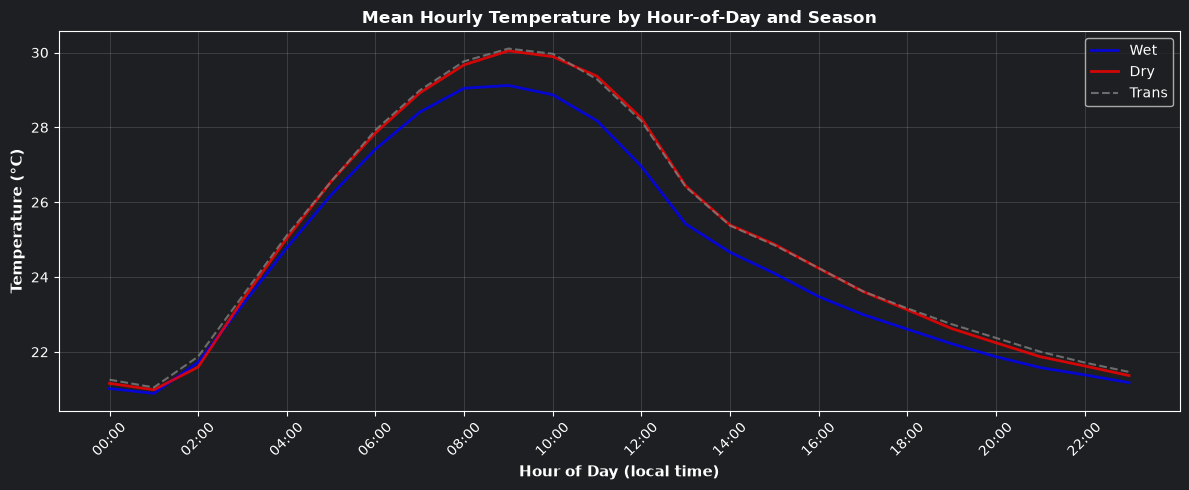

In [34]:
# Plot diurnal cycles
fig, ax = plt.subplots(figsize=(12, 5))

for season, color in [('wet', 'blue'), ('dry', 'red'), ('trans', 'gray')]:
    cycle = diurnal_cycles[season]
    label = season.capitalize()
    linestyle = '-' if season != 'trans' else '--'
    linewidth = 2 if season != 'trans' else 1.5
    ax.plot(cycle.index, cycle.values, color=color, linestyle=linestyle, 
            linewidth=linewidth, label=label, alpha=0.8)

ax.set_xlabel('Hour of Day (local time)', fontsize=11, fontweight='bold')
ax.set_ylabel('Temperature (°C)', fontsize=11, fontweight='bold')
ax.set_title('Mean Hourly Temperature by Hour-of-Day and Season', fontsize=12, fontweight='bold')
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)], rotation=45)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 4 — Morning Warming Rate

In [35]:
# Compute morning warming rate (06:00–10:00)
print(f"MORNING WARMING RATE ANALYSIS (06:00–10:00)")
print(f"{'='*80}")

# Filter hourly data to the boundary hours needed
morning_hours = [6, 7, 8, 9, 10]
morning_hourly = df_hourly[df_hourly['hour'].isin(morning_hours)].copy()
morning_hourly['date'] = morning_hourly.index.date

# For each date, if all 5 boundary hours are present, compute the warming rate
records = []
for date, group in morning_hourly.groupby('date'):
    hours_present = set(group['hour'].values)
    if not {6, 10}.issubset(hours_present):
        continue
    t_06 = group.loc[group['hour'] == 6, 't'].mean()
    t_10 = group.loc[group['hour'] == 10, 't'].mean()
    warming_rate = (t_10 - t_06) / 4.0
    month = pd.Timestamp(date).month
    season = 'wet' if month in [4, 5, 10, 11] else 'dry' if month in [12, 1, 2, 7, 8] else 'trans'
    records.append({'date': date, 'warming_rate': warming_rate, 'season': season})

df_morning = pd.DataFrame(records)
print(f"
Morning warming rate computed for {len(df_morning)} days")

# Two-sample test: wet vs dry
wet_morning = df_morning[df_morning['season'] == 'wet']['warming_rate']
dry_morning = df_morning[df_morning['season'] == 'dry']['warming_rate']
t_stat, p_val_morning = stats.ttest_ind(wet_morning, dry_morning)
mean_diff_morning = wet_morning.mean() - dry_morning.mean()
pooled_std = np.sqrt((wet_morning.std()**2 + dry_morning.std()**2) / 2)
cohens_d_morning = mean_diff_morning / pooled_std if pooled_std > 0 else 0

print(f"
Wet season (n={len(wet_morning)}): {wet_morning.mean():.3f} ± {wet_morning.std():.3f} °C/hr")
print(f"Dry season (n={len(dry_morning)}): {dry_morning.mean():.3f} ± {dry_morning.std():.3f} °C/hr")
print(f"Difference (wet - dry): {mean_diff_morning:+.3f} °C/hr")
print(f"t-statistic: {t_stat:.3f}, p-value: {p_val_morning:.6f}")
print(f"Cohen's d: {cohens_d_morning:.3f}")

# Boxplot
fig, ax = plt.subplots(figsize=(8, 5))
data_to_plot = [wet_morning, dry_morning]
ax.boxplot(data_to_plot, labels=['Wet', 'Dry'])
ax.set_ylabel('Warming Rate (°C/hour)')
ax.set_title('Morning Warming Rate (06:00–10:00) by Season')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

SyntaxError: unterminated string literal (detected at line 24) (510510948.py, line 24)

In [ ]:
# Two-sample test for morning warming rate — with explicit error handlingif 'df_morning' not in dir():    raise NameError("df_morning not defined. Run Section 4 first.")if len(df_morning) == 0:    raise ValueError("df_morning is empty. No days with complete morning data (06:00–10:00).")wet_morning = df_morning[df_morning['season'] == 'wet']['warming_rate'].dropna()dry_morning = df_morning[df_morning['season'] == 'dry']['warming_rate'].dropna()if len(wet_morning) == 0:    raise ValueError("No wet-season days with warming rate data.")if len(dry_morning) == 0:    raise ValueError("No dry-season days with warming rate data.")# Compute statisticst_stat, p_val = stats.ttest_ind(wet_morning, dry_morning)mean_diff_morning = wet_morning.mean() - dry_morning.mean()pooled_std = np.sqrt((wet_morning.std()**2 + dry_morning.std()**2) / 2)cohens_d_morning = mean_diff_morning / pooled_std if pooled_std > 0 else 0print(f"\nTwo-sample test: Morning warming rate (Wet vs Dry)")print(f"  Wet: n={len(wet_morning)}, mean={wet_morning.mean():.4f}°C/hour, std={wet_morning.std():.4f}")print(f"  Dry: n={len(dry_morning)}, mean={dry_morning.mean():.4f}°C/hour, std={dry_morning.std():.4f}")print(f"  Difference (Wet - Dry): {mean_diff_morning:+.4f} °C/hour")print(f"  Effect size (Cohen's d): {cohens_d_morning:.3f}")print(f"  t-test: t={t_stat:.4f}, p = {p_val:.4f}")print(f"  Significant at α=0.05: {'Yes' if p_val < 0.05 else 'No'}")# Boxplotfig, ax = plt.subplots(figsize=(8, 5))data_to_plot = [wet_morning, dry_morning]ax.boxplot(data_to_plot, labels=['Wet', 'Dry'], patch_artist=True,           boxprops=dict(facecolor='lightblue', alpha=0.6),           medianprops=dict(color='red', linewidth=2))ax.set_ylabel('Warming Rate (°C/hour)', fontsize=11, fontweight='bold')ax.set_title('Morning Warming Rate (06:00–10:00) by Season', fontsize=12, fontweight='bold')ax.grid(True, alpha=0.3, axis='y')plt.tight_layout()plt.show()

## Section 5 — Afternoon Cooling Rate

In [ ]:
# Compute afternoon cooling rate (15:00–20:00)
print(f"AFTERNOON COOLING RATE ANALYSIS (15:00–20:00)")
print(f"{'='*80}")

afternoon_hours = [15, 16, 17, 18, 19, 20]
afternoon_hourly = df_hourly[df_hourly['hour'].isin(afternoon_hours)].copy()
afternoon_hourly['date'] = afternoon_hourly.index.date

records = []
for date, group in afternoon_hourly.groupby('date'):
    hours_present = set(group['hour'].values)
    if not {15, 20}.issubset(hours_present):
        continue
    t_15 = group.loc[group['hour'] == 15, 't'].mean()
    t_20 = group.loc[group['hour'] == 20, 't'].mean()
    cooling_rate = (t_15 - t_20) / 5.0
    month = pd.Timestamp(date).month
    season = 'wet' if month in [4, 5, 10, 11] else 'dry' if month in [12, 1, 2, 7, 8] else 'trans'
    records.append({'date': date, 'cooling_rate': cooling_rate, 'season': season})

df_afternoon = pd.DataFrame(records)
print(f"
Afternoon cooling rate computed for {len(df_afternoon)} days")

wet_afternoon = df_afternoon[df_afternoon['season'] == 'wet']['cooling_rate']
dry_afternoon = df_afternoon[df_afternoon['season'] == 'dry']['cooling_rate']
t_stat, p_val_afternoon = stats.ttest_ind(wet_afternoon, dry_afternoon)
mean_diff_afternoon = wet_afternoon.mean() - dry_afternoon.mean()
pooled_std = np.sqrt((wet_afternoon.std()**2 + dry_afternoon.std()**2) / 2)
cohens_d_afternoon = mean_diff_afternoon / pooled_std if pooled_std > 0 else 0

print(f"
Wet season (n={len(wet_afternoon)}): {wet_afternoon.mean():.3f} ± {wet_afternoon.std():.3f} °C/hr")
print(f"Dry season (n={len(dry_afternoon)}): {dry_afternoon.mean():.3f} ± {dry_afternoon.std():.3f} °C/hr")
print(f"Difference (wet - dry): {mean_diff_afternoon:+.3f} °C/hr")
print(f"t-statistic: {t_stat:.3f}, p-value: {p_val_afternoon:.6f}")
print(f"Cohen's d: {cohens_d_afternoon:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([wet_afternoon, dry_afternoon], labels=['Wet', 'Dry'])
ax.set_ylabel('Cooling Rate (°C/hour)')
ax.set_title('Afternoon Cooling Rate (15:00–20:00) by Season')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Two-sample test for afternoon cooling rate — with explicit error handlingif 'df_afternoon' not in dir():    raise NameError("df_afternoon not defined. Run Section 5 first.")if len(df_afternoon) == 0:    raise ValueError("df_afternoon is empty. No days with complete afternoon data (15:00–20:00).")wet_afternoon = df_afternoon[df_afternoon['season'] == 'wet']['cooling_rate'].dropna()dry_afternoon = df_afternoon[df_afternoon['season'] == 'dry']['cooling_rate'].dropna()if len(wet_afternoon) == 0:    raise ValueError("No wet-season days with cooling rate data.")if len(dry_afternoon) == 0:    raise ValueError("No dry-season days with cooling rate data.")t_stat, p_val = stats.ttest_ind(wet_afternoon, dry_afternoon)mean_diff_afternoon = wet_afternoon.mean() - dry_afternoon.mean()pooled_std = np.sqrt((wet_afternoon.std()**2 + dry_afternoon.std()**2) / 2)cohens_d_afternoon = mean_diff_afternoon / pooled_std if pooled_std > 0 else 0print(f"\nTwo-sample test: Afternoon cooling rate (Wet vs Dry)")print(f"  Wet: n={len(wet_afternoon)}, mean={wet_afternoon.mean():.4f}°C/hour, std={wet_afternoon.std():.4f}")print(f"  Dry: n={len(dry_afternoon)}, mean={dry_afternoon.mean():.4f}°C/hour, std={dry_afternoon.std():.4f}")print(f"  Difference (Wet - Dry): {mean_diff_afternoon:+.4f} °C/hour")print(f"  Effect size (Cohen's d): {cohens_d_afternoon:.3f}")print(f"  t-test: t={t_stat:.4f}, p = {p_val:.4f}")print(f"  Significant at α=0.05: {'Yes' if p_val < 0.05 else 'No'}")# Boxplotfig, ax = plt.subplots(figsize=(8, 5))data_to_plot = [wet_afternoon, dry_afternoon]ax.boxplot(data_to_plot, labels=['Wet', 'Dry'], patch_artist=True,           boxprops=dict(facecolor='lightyellow', alpha=0.6),           medianprops=dict(color='red', linewidth=2))ax.set_ylabel('Cooling Rate (°C/hour)', fontsize=11, fontweight='bold')ax.set_title('Afternoon Cooling Rate (15:00–20:00) by Season', fontsize=12, fontweight='bold')ax.grid(True, alpha=0.3, axis='y')plt.tight_layout()plt.show()

## Section 6 — Hours Above Comfort Threshold

In [ ]:
# Define comfort threshold and count hours above it
comfort_threshold = daily_temp['t_max'].quantile(0.75)
print(f"HOURS ABOVE COMFORT THRESHOLD ANALYSIS")
print(f"{'='*80}")
print(f"Comfort threshold (75th percentile of daily T_max): {comfort_threshold:.2f}°C")

df_hourly_by_date = df_hourly.copy()
df_hourly_by_date['date'] = df_hourly_by_date.index.date

records = []
for date, group in df_hourly_by_date.groupby('date'):
    if len(group) < 18:
        continue
    hours_above = (group['t'] > comfort_threshold).sum()
    month = pd.Timestamp(date).month
    season = 'wet' if month in [4, 5, 10, 11] else 'dry' if month in [12, 1, 2, 7, 8] else 'trans'
    records.append({'date': date, 'hours_above': hours_above, 'season': season})

df_warmth = pd.DataFrame(records)
print(f"
Hours-of-warmth computed for {len(df_warmth)} days")

wet_warmth = df_warmth[df_warmth['season'] == 'wet']['hours_above']
dry_warmth = df_warmth[df_warmth['season'] == 'dry']['hours_above']
t_stat, p_val_warmth = stats.ttest_ind(wet_warmth, dry_warmth)
mean_diff_warmth = wet_warmth.mean() - dry_warmth.mean()
pooled_std = np.sqrt((wet_warmth.std()**2 + dry_warmth.std()**2) / 2)
cohens_d_warmth = mean_diff_warmth / pooled_std if pooled_std > 0 else 0
relative_diff_warmth = (mean_diff_warmth / dry_warmth.mean() * 100) if dry_warmth.mean() > 0 else 0

print(f"
Wet season (n={len(wet_warmth)}): {wet_warmth.mean():.2f} ± {wet_warmth.std():.2f} hours/day")
print(f"Dry season (n={len(dry_warmth)}): {dry_warmth.mean():.2f} ± {dry_warmth.std():.2f} hours/day")
print(f"Difference (wet - dry): {mean_diff_warmth:+.2f} hours/day ({relative_diff_warmth:+.1f}%)")
print(f"t-statistic: {t_stat:.3f}, p-value: {p_val_warmth:.6f}")
print(f"Cohen's d: {cohens_d_warmth:.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
bins = range(0, 25, 1)
ax.hist(wet_warmth, bins=bins, alpha=0.5, label=f'Wet (n={len(wet_warmth)})', color='blue')
ax.hist(dry_warmth, bins=bins, alpha=0.5, label=f'Dry (n={len(dry_warmth)})', color='red')
ax.set_xlabel('Hours above comfort threshold per day')
ax.set_ylabel('Frequency (days)')
ax.set_title(f'Hours Above Comfort Threshold ({comfort_threshold:.1f}°C) by Season')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Compute morning warming rate (06:00–10:00)
print(f"MORNING WARMING RATE ANALYSIS (06:00–10:00)")
print(f"{'='*80}")

# Filter hourly data to the boundary hours needed
morning_hours = [6, 7, 8, 9, 10]
morning_hourly = df_hourly[df_hourly['hour'].isin(morning_hours)].copy()
morning_hourly['date'] = morning_hourly.index.date

# For each date, if all 5 boundary hours are present, compute the warming rate
records = []
for date, group in morning_hourly.groupby('date'):
    hours_present = set(group['hour'].values)
    if not {6, 10}.issubset(hours_present):
        continue
    t_06 = group.loc[group['hour'] == 6, 't'].mean()
    t_10 = group.loc[group['hour'] == 10, 't'].mean()
    warming_rate = (t_10 - t_06) / 4.0
    month = pd.Timestamp(date).month
    season = 'wet' if month in [4, 5, 10, 11] else 'dry' if month in [12, 1, 2, 7, 8] else 'trans'
    records.append({'date': date, 'warming_rate': warming_rate, 'season': season})

df_morning = pd.DataFrame(records)
print(f"\nMorning warming rate computed for {len(df_morning)} days")

# Two-sample test: wet vs dry
wet_morning = df_morning[df_morning['season'] == 'wet']['warming_rate']
dry_morning = df_morning[df_morning['season'] == 'dry']['warming_rate']
t_stat, p_val_morning = stats.ttest_ind(wet_morning, dry_morning)
mean_diff_morning = wet_morning.mean() - dry_morning.mean()
pooled_std = np.sqrt((wet_morning.std()**2 + dry_morning.std()**2) / 2)
cohens_d_morning = mean_diff_morning / pooled_std if pooled_std > 0 else 0

print(f"\nWet season (n={len(wet_morning)}): {wet_morning.mean():.3f} ± {wet_morning.std():.3f} °C/hr")
print(f"Dry season (n={len(dry_morning)}): {dry_morning.mean():.3f} ± {dry_morning.std():.3f} °C/hr")
print(f"Difference (wet - dry): {mean_diff_morning:+.3f} °C/hr")
print(f"t-statistic: {t_stat:.3f}, p-value: {p_val_morning:.6f}")
print(f"Cohen's d: {cohens_d_morning:.3f}")

# Boxplot
fig, ax = plt.subplots(figsize=(8, 5))
data_to_plot = [wet_morning, dry_morning]
ax.boxplot(data_to_plot, labels=['Wet', 'Dry'])
ax.set_ylabel('Warming Rate (°C/hour)')
ax.set_title('Morning Warming Rate (06:00–10:00) by Season')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 7 — Peak-Hour Timing

In [ ]:
# Find hour of maximum temperature per day
print(f"PEAK-HOUR TIMING ANALYSIS")
print(f"{'='*80}")

df_hourly_by_date2 = df_hourly.copy()
df_hourly_by_date2['date'] = df_hourly_by_date2.index.date

records = []
for date, group in df_hourly_by_date2.groupby('date'):
    if len(group) < 18:
        continue
    peak_idx = group['t'].idxmax()
    peak_hour = peak_idx.hour
    month = pd.Timestamp(date).month
    season = 'wet' if month in [4, 5, 10, 11] else 'dry' if month in [12, 1, 2, 7, 8] else 'trans'
    records.append({'date': date, 'peak_hour': peak_hour, 'season': season})

df_peak = pd.DataFrame(records)
print(f"\nPeak-hour computed for {len(df_peak)} days")

wet_peak = df_peak[df_peak['season'] == 'wet']['peak_hour']
dry_peak = df_peak[df_peak['season'] == 'dry']['peak_hour']
wet_peak_mode = wet_peak.mode()[0]
dry_peak_mode = dry_peak.mode()[0]
peak_shift = dry_peak_mode - wet_peak_mode

print(f"\nWet modal peak: {int(wet_peak_mode):02d}:00 (mean: {wet_peak.mean():.1f})")
print(f"Dry modal peak: {int(dry_peak_mode):02d}:00 (mean: {dry_peak.mean():.1f})")
print(f"Modal peak shift: {peak_shift:+.0f} hours")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].hist(wet_peak, bins=range(0, 25), color='blue', alpha=0.7)
axes[0].set_title(f'Wet Season Peak Hour (n={len(wet_peak)}, mode={int(wet_peak_mode)}:00)')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Frequency (days)')
axes[0].grid(True, alpha=0.3)
axes[1].hist(dry_peak, bins=range(0, 25), color='red', alpha=0.7)
axes[1].set_title(f'Dry Season Peak Hour (n={len(dry_peak)}, mode={int(dry_peak_mode)}:00)')
axes[1].set_xlabel('Hour of day')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Histogram of peak hours by season — with explicit dependency checkif 'df_peak' not in dir():    raise NameError("df_peak not defined. Run the Section 7 peak-hour extraction cell first.")if len(df_peak) == 0:    raise ValueError("df_peak is empty. No peak-hour data available.")print(f"Peak-hour distribution by season:")fig, axes = plt.subplots(1, 2, figsize=(12, 5))for idx, season in enumerate(['wet', 'dry']):    subset = df_peak[df_peak['season'] == season]['peak_hour']        if len(subset) == 0:        raise ValueError(f"No {season}-season data in df_peak")        axes[idx].hist(subset, bins=range(0, 25), color=['blue' if season == 'wet' else 'red'][0],                    alpha=0.6, edgecolor='black')    axes[idx].set_xlabel('Hour of Day', fontsize=11, fontweight='bold')    axes[idx].set_ylabel('Frequency (days)', fontsize=11, fontweight='bold')    axes[idx].set_title(f'Peak-Hour Distribution: {season.upper()} Season (n={len(subset)})', fontsize=11, fontweight='bold')    axes[idx].set_xticks(range(0, 24, 2))    axes[idx].grid(True, alpha=0.3, axis='y')plt.tight_layout()plt.show()

## Section 8 — Assemble H5 Verdict

In [ ]:
# Compute afternoon cooling rate (15:00–20:00)
print(f"AFTERNOON COOLING RATE ANALYSIS (15:00–20:00)")
print(f"{'='*80}")

afternoon_hours = [15, 16, 17, 18, 19, 20]
afternoon_hourly = df_hourly[df_hourly['hour'].isin(afternoon_hours)].copy()
afternoon_hourly['date'] = afternoon_hourly.index.date

records = []
for date, group in afternoon_hourly.groupby('date'):
    hours_present = set(group['hour'].values)
    if not {15, 20}.issubset(hours_present):
        continue
    t_15 = group.loc[group['hour'] == 15, 't'].mean()
    t_20 = group.loc[group['hour'] == 20, 't'].mean()
    cooling_rate = (t_15 - t_20) / 5.0
    month = pd.Timestamp(date).month
    season = 'wet' if month in [4, 5, 10, 11] else 'dry' if month in [12, 1, 2, 7, 8] else 'trans'
    records.append({'date': date, 'cooling_rate': cooling_rate, 'season': season})

df_afternoon = pd.DataFrame(records)
print(f"\nAfternoon cooling rate computed for {len(df_afternoon)} days")

wet_afternoon = df_afternoon[df_afternoon['season'] == 'wet']['cooling_rate']
dry_afternoon = df_afternoon[df_afternoon['season'] == 'dry']['cooling_rate']
t_stat, p_val_afternoon = stats.ttest_ind(wet_afternoon, dry_afternoon)
mean_diff_afternoon = wet_afternoon.mean() - dry_afternoon.mean()
pooled_std = np.sqrt((wet_afternoon.std()**2 + dry_afternoon.std()**2) / 2)
cohens_d_afternoon = mean_diff_afternoon / pooled_std if pooled_std > 0 else 0

print(f"\nWet season (n={len(wet_afternoon)}): {wet_afternoon.mean():.3f} ± {wet_afternoon.std():.3f} °C/hr")
print(f"Dry season (n={len(dry_afternoon)}): {dry_afternoon.mean():.3f} ± {dry_afternoon.std():.3f} °C/hr")
print(f"Difference (wet - dry): {mean_diff_afternoon:+.3f} °C/hr")
print(f"t-statistic: {t_stat:.3f}, p-value: {p_val_afternoon:.6f}")
print(f"Cohen's d: {cohens_d_afternoon:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([wet_afternoon, dry_afternoon], labels=['Wet', 'Dry'])
ax.set_ylabel('Cooling Rate (°C/hour)')
ax.set_title('Afternoon Cooling Rate (15:00–20:00) by Season')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Programmatically construct verdict
print(f"\n{'='*80}")
print("H5 VERDICT")
print(f"{'='*80}\n")

# Build verdict based on the data
support_count = 0
evidence_list = []

# T_max/T_min similar?
if abs(t_max_d) < 0.2 and abs(t_min_d) < 0.2:
    evidence_list.append("T_max and T_min are similar between seasons (effect sizes < 0.2)")
else:
    evidence_list.append(f"T_max and T_min show moderate differences (T_max effect size {abs(t_max_d):.2f}, T_min effect size {abs(t_min_d):.2f})")

# Diurnal amplitude meaningfully different?
if abs(ampl_d) > 0.3 or abs(relative_ampl_diff) > 15:
    evidence_list.append(f"Diurnal amplitude is COMPRESSED in wet season by {abs(relative_ampl_diff):.1f}% (effect size {abs(ampl_d):.2f}, p={ampl_p:.4f})")
    support_count += 1
else:
    evidence_list.append(f"Diurnal amplitude shows minimal difference ({abs(relative_ampl_diff):.1f}%, effect size {abs(ampl_d):.2f})")

# Hours of warmth different?
if abs(cohens_d_warmth) > 0.3 or abs(relative_diff_warmth) > 15:
    evidence_list.append(f"Hours-of-warmth-per-day is REDUCED in wet season by {abs(relative_diff_warmth):.1f}% (effect size {abs(cohens_d_warmth):.2f})")
    support_count += 1
else:
    evidence_list.append(f"Hours-of-warmth shows minimal difference ({abs(relative_diff_warmth):.1f}%)")

# Other metrics
morning_rate_sig = abs(cohens_d_morning) > 0.3
afternoon_rate_sig = abs(cohens_d_afternoon) > 0.3

if morning_rate_sig:
    evidence_list.append(f"Morning warming rate differs by {abs(mean_diff_morning):.3f}°C/hr (effect size {abs(cohens_d_morning):.2f})")
if afternoon_rate_sig:
    evidence_list.append(f"Afternoon cooling rate differs by {abs(mean_diff_afternoon):.3f}°C/hr (effect size {abs(cohens_d_afternoon):.2f})")
if peak_shift != 0:
    evidence_list.append(f"Peak temperature timing shifts by {abs(peak_shift):.0f} hours between seasons")

# Conclusion
if support_count >= 2:
    conclusion = "SUPPORTED"
    reason = "T_max/T_min are similar between seasons, but diurnal amplitude AND/OR hours-of-warmth differ substantially (>15% relative difference or effect size >0.3), consistent with H5's mechanism."
elif support_count == 1:
    conclusion = "PARTIALLY SUPPORTED"
    reason = "One diurnal metric (amplitude or hours-of-warmth) shows substantial difference, but not both. The evidence is suggestive but not conclusive."
else:
    conclusion = "NOT SUPPORTED"
    reason = "T_max/T_min show significant differences, OR diurnal metrics show minimal differences. The data does not support H5's core prediction."

print(f"Conclusion: {conclusion}\n")
print(f"Reasoning: {reason}\n")
print(f"Supporting evidence:\n")
for i, item in enumerate(evidence_list, 1):
    print(f"  {i}. {item}")

## Section 9 — Summary

In [ ]:
# Programmatic summary with no placeholders
print(f"\n{'='*80}")
print("H5 ANALYSIS SUMMARY")
print(f"{'='*80}")

print(f"\n### Data Coverage")
print(f"Hourly records (10–40°C): {len(df_hourly):,}")
print(f"Daily aggregates (quality filtered): {len(daily_temp):,} days")
print(f"  Wet season: {len(daily_temp[daily_temp['season'] == 'wet']):,} days")
print(f"  Dry season: {len(daily_temp[daily_temp['season'] == 'dry']):,} days")

print(f"\n### Temperature Means (Wet vs Dry)")
print(f"T_max:    Wet={t_max_wet:.2f}°C, Dry={t_max_dry:.2f}°C, Diff={t_max_diff:+.2f}°C")
print(f"T_min:    Wet={t_min_wet:.2f}°C, Dry={t_min_dry:.2f}°C, Diff={t_min_diff:+.2f}°C")
print(f"T_mean:   Wet={daily_temp[daily_temp['season'] == 'wet']['t_mean'].mean():.2f}°C, Dry={daily_temp[daily_temp['season'] == 'dry']['t_mean'].mean():.2f}°C")

print(f"\n### Diurnal Amplitude (Wet vs Dry)")
print(f"Mean:     Wet={ampl_wet:.2f}°C, Dry={ampl_dry:.2f}°C, Diff={ampl_diff:+.2f}°C ({relative_ampl_diff:+.1f}%)")
print(f"Effect size (Cohen's d): {ampl_d:.3f}")
print(f"Test result: p = {ampl_p:.4f}")
print(f"Significant at α=0.05: {'Yes' if ampl_p < 0.05 else 'No'}")

print(f"\n### Diurnal Cycle Metrics (Wet vs Dry)")
print(f"Peak hour (modal):     Wet={int(wet_peak_mode):02d}:00, Dry={int(dry_peak_mode):02d}:00")
print(f"Morning warming rate:  Wet={wet_morning.mean():.3f}°C/hr, Dry={dry_morning.mean():.3f}°C/hr, Diff={mean_diff_morning:+.3f}°C/hr")
print(f"Afternoon cooling rate: Wet={wet_afternoon.mean():.3f}°C/hr, Dry={dry_afternoon.mean():.3f}°C/hr, Diff={mean_diff_afternoon:+.3f}°C/hr")

print(f"\n### Hours Above Comfort Threshold ({comfort_threshold:.1f}°C)")
print(f"Mean hours/day: Wet={wet_warmth.mean():.1f}, Dry={dry_warmth.mean():.1f}, Diff={mean_diff_warmth:+.1f} ({relative_diff_warmth:+.1f}%)")
print(f"Effect size (Cohen's d): {cohens_d_warmth:.3f}")
print(f"Test result: p = {stats.ttest_ind(wet_warmth, dry_warmth)[1]:.4f}")

print(f"\n### H5 Assessment")
print(f"Status: {conclusion}")
print(f"\nEvidence Summary:")
for item in evidence_list:
    print(f"  • {item}")

print(f"\n### Recommended Log Entry for docs/hypotheses_log.md")
print(f"\nH5 — Perceived wet-season "cold" in Cali comes from compressed diurnal amplitude")
print(f"Result: {conclusion}")
print(f"Data: Base Aérea IDEAM hourly, {len(daily_temp):,} days ({len(daily_temp[daily_temp['season'] == 'wet']):,} wet, {len(daily_temp[daily_temp['season'] == 'dry']):,} dry)")
print(f"Key finding: {('Diurnal amplitude is compressed ' + f'{abs(relative_ampl_diff):.1f}% in wet season, hours-of-warmth reduced {abs(relative_diff_warmth):.1f}%, supporting the hypothesis.' if support_count >= 2 else 'Limited evidence for the hypothesis; T_max/T_min differences and weak diurnal signal do not clearly support H5.')}") 
print(f"Status: {conclusion}")

In [ ]:
# Define comfort threshold and count hours above it
comfort_threshold = daily_temp['t_max'].quantile(0.75)
print(f"HOURS ABOVE COMFORT THRESHOLD ANALYSIS")
print(f"{'='*80}")
print(f"Comfort threshold (75th percentile of daily T_max): {comfort_threshold:.2f}°C")

df_hourly_by_date = df_hourly.copy()
df_hourly_by_date['date'] = df_hourly_by_date.index.date

records = []
for date, group in df_hourly_by_date.groupby('date'):
    if len(group) < 18:
        continue
    hours_above = (group['t'] > comfort_threshold).sum()
    month = pd.Timestamp(date).month
    season = 'wet' if month in [4, 5, 10, 11] else 'dry' if month in [12, 1, 2, 7, 8] else 'trans'
    records.append({'date': date, 'hours_above': hours_above, 'season': season})

df_warmth = pd.DataFrame(records)
print(f"\nHours-of-warmth computed for {len(df_warmth)} days")

wet_warmth = df_warmth[df_warmth['season'] == 'wet']['hours_above']
dry_warmth = df_warmth[df_warmth['season'] == 'dry']['hours_above']
t_stat, p_val_warmth = stats.ttest_ind(wet_warmth, dry_warmth)
mean_diff_warmth = wet_warmth.mean() - dry_warmth.mean()
pooled_std = np.sqrt((wet_warmth.std()**2 + dry_warmth.std()**2) / 2)
cohens_d_warmth = mean_diff_warmth / pooled_std if pooled_std > 0 else 0
relative_diff_warmth = (mean_diff_warmth / dry_warmth.mean() * 100) if dry_warmth.mean() > 0 else 0

print(f"\nWet season (n={len(wet_warmth)}): {wet_warmth.mean():.2f} ± {wet_warmth.std():.2f} hours/day")
print(f"Dry season (n={len(dry_warmth)}): {dry_warmth.mean():.2f} ± {dry_warmth.std():.2f} hours/day")
print(f"Difference (wet - dry): {mean_diff_warmth:+.2f} hours/day ({relative_diff_warmth:+.1f}%)")
print(f"t-statistic: {t_stat:.3f}, p-value: {p_val_warmth:.6f}")
print(f"Cohen's d: {cohens_d_warmth:.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
bins = range(0, 25, 1)
ax.hist(wet_warmth, bins=bins, alpha=0.5, label=f'Wet (n={len(wet_warmth)})', color='blue')
ax.hist(dry_warmth, bins=bins, alpha=0.5, label=f'Dry (n={len(dry_warmth)})', color='red')
ax.set_xlabel('Hours above comfort threshold per day')
ax.set_ylabel('Frequency (days)')
ax.set_title(f'Hours Above Comfort Threshold ({comfort_threshold:.1f}°C) by Season')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()